# 5주차: Deep Neural Network - 해설

In [1]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split
torch.manual_seed(42); np.random.seed(42)


In [2]:
class DNN(nn.Module):
    def __init__(self, layer_dims):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(layer_dims[i], layer_dims[i+1]) for i in range(len(layer_dims)-1)
        ])
    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers)-1: x = torch.relu(x)
        return torch.sigmoid(x)
    def count_params(self):
        return sum(p.numel() for p in self.parameters())


### A-1

In [3]:
x=torch.randn(32,4); fc1=nn.Linear(4,16); fc2=nn.Linear(16,8); fc3=nn.Linear(8,1)
a1=torch.relu(fc1(x));    print("After fc1+ReLU:   ", a1.shape)
a2=torch.relu(fc2(a1));   print("After fc2+ReLU:   ", a2.shape)
out=torch.sigmoid(fc3(a2)); print("After fc3+Sigmoid:", out.shape)


After fc1+ReLU:    torch.Size([32, 16])
After fc2+ReLU:    torch.Size([32, 8])
After fc3+Sigmoid: torch.Size([32, 1])


### A-2

In [4]:
class MyDNN(nn.Module):
    def __init__(self, layer_dims):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(layer_dims[i],layer_dims[i+1]) for i in range(len(layer_dims)-1)])
    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:   # ← 정답
                x = torch.relu(x)
            else:
                x = torch.sigmoid(x)
        return x
print("Output shape:", MyDNN([3,8,4,1])(torch.randn(10,3)).shape)


Output shape: torch.Size([10, 1])


### A-3

In [5]:
params_A = DNN([2,32,1]).count_params()     # ← 정답: 129
params_B = DNN([2,8,8,8,1]).count_params()  # ← 정답: 177
print(f"Model A: {params_A}")   # 2*32+32 + 32*1+1 = 129
print(f"Model B: {params_B}")   # 24+72+72+9 = 177


Model A: 129
Model B: 177


### A-4

In [6]:
class GoodDNN(nn.Module):
    def __init__(self): super().__init__(); self.layers=nn.ModuleList([nn.Linear(2,4),nn.Linear(4,1)])
class BadDNN(nn.Module):
    def __init__(self): super().__init__(); self.layers=[nn.Linear(2,4),nn.Linear(4,1)]

good_params = sum(p.numel() for p in GoodDNN().parameters())   # ← 정답: 21
bad_params  = sum(p.numel() for p in BadDNN().parameters())    # ← 정답: 0
print(f"GoodDNN: {good_params}"); print(f"BadDNN:  {bad_params}")


GoodDNN: 17
BadDNN:  0


### A-5

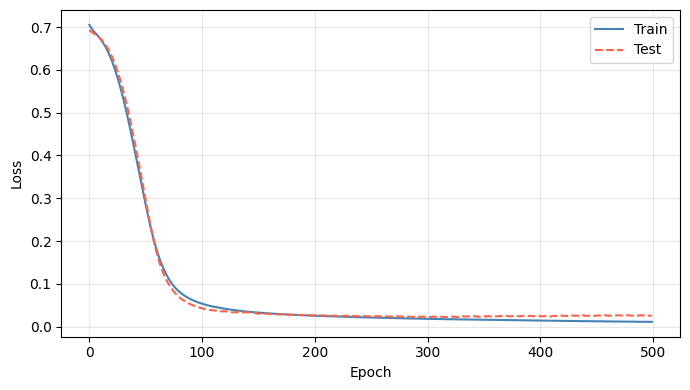

In [7]:
X_np2,y_np2=make_circles(n_samples=400,noise=0.15,factor=0.4,random_state=0)
X_tr2,X_te2,y_tr2,y_te2=train_test_split(X_np2,y_np2,test_size=0.2,random_state=0)
X_train2=torch.tensor(X_tr2,dtype=torch.float32); y_train2=torch.tensor(y_tr2,dtype=torch.float32).unsqueeze(1)
X_test2 =torch.tensor(X_te2,dtype=torch.float32); y_test2 =torch.tensor(y_te2,dtype=torch.float32).unsqueeze(1)
torch.manual_seed(42)
model_a5=DNN([2,16,8,1]); opt_a5=torch.optim.Adam(model_a5.parameters(),lr=0.01); crit_a5=nn.BCELoss()
train_losses,test_losses=[],[]
for epoch in range(500):
    model_a5.train()   # ← 정답
    opt_a5.zero_grad(); loss=crit_a5(model_a5(X_train2),y_train2); loss.backward(); opt_a5.step()
    train_losses.append(loss.item())
    model_a5.eval()    # ← 정답
    with torch.no_grad(): test_losses.append(crit_a5(model_a5(X_test2),y_test2).item())
plt.figure(figsize=(7,4))
plt.plot(train_losses,label='Train',color='steelblue'); plt.plot(test_losses,label='Test',color='tomato',linestyle='--')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True,alpha=0.3); plt.tight_layout(); plt.show()


### A-6

In [8]:
archs=[[2,128,1],[2,64,64,1],[2,32,32,32,1],[2,16,16,16,16,1],[2,8,8,8,8,8,1]]
print(f"{'Architecture':35s} {'Depth':>6s} {'Params':>8s}"); print("-"*55)
for dims in archs:
    depth  = len(dims) - 2            # ← 정답
    params = DNN(dims).count_params() # ← 정답
    print(f"{str(dims):35s} {depth:>6d} {params:>8,}")


Architecture                         Depth   Params
-------------------------------------------------------
[2, 128, 1]                              1      513
[2, 64, 64, 1]                           2    4,417
[2, 32, 32, 32, 1]                       3    2,241
[2, 16, 16, 16, 16, 1]                   4      881
[2, 8, 8, 8, 8, 8, 1]                    5      321


### A-7

In [9]:
X_np3,y_np3=make_circles(n_samples=400,noise=0.15,factor=0.4,random_state=0)
X_tr3,X_te3,y_tr3,y_te3=train_test_split(X_np3,y_np3,test_size=0.2,random_state=0)
X_train3=torch.tensor(X_tr3,dtype=torch.float32); y_train3=torch.tensor(y_tr3,dtype=torch.float32).unsqueeze(1)
X_test3 =torch.tensor(X_te3,dtype=torch.float32); y_test3 =torch.tensor(y_te3,dtype=torch.float32).unsqueeze(1)
torch.manual_seed(42)
model_save=DNN([2,16,8,1]); opt_s=torch.optim.Adam(model_save.parameters(),lr=0.01); crit_s=nn.BCELoss()
for _ in range(300):
    opt_s.zero_grad(); l=crit_s(model_save(X_train3),y_train3); l.backward(); opt_s.step()
torch.save(model_save.state_dict(), "/tmp/my_dnn.pth")   # ← 정답
model_load=DNN([2,16,8,1])
model_load.load_state_dict(torch.load("/tmp/my_dnn.pth", weights_only=True))  # ← 정답
model_load.eval()
with torch.no_grad():
    acc=((model_load(X_test3)>0.5).float()==y_test3).float().mean().item()
print(f"Loaded acc: {acc*100:.1f}%")


Loaded acc: 98.8%


### A-8

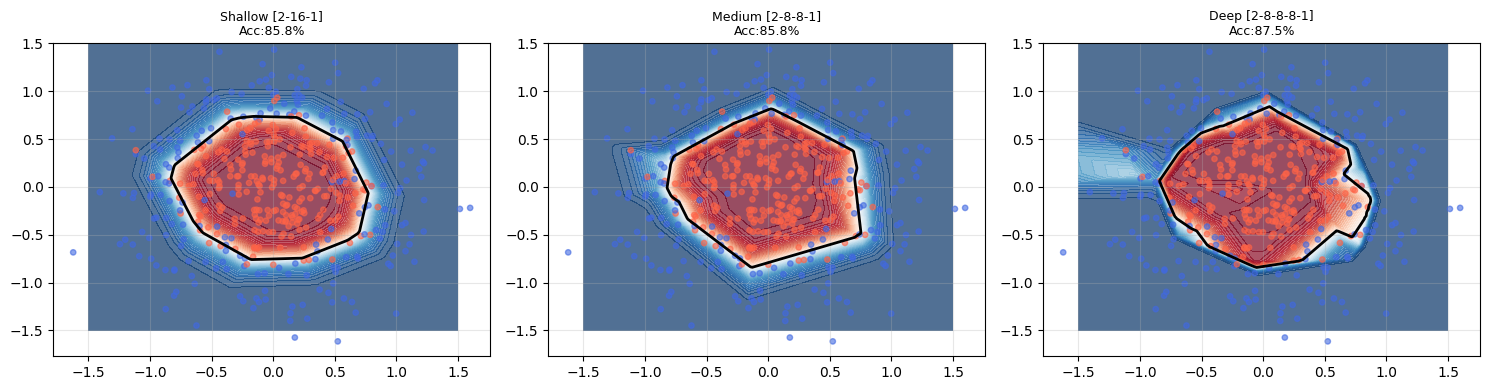

In [10]:
X_np4,y_np4=make_circles(n_samples=600,noise=0.25,factor=0.4,random_state=0)
X_tr4,X_te4,y_tr4,y_te4=train_test_split(X_np4,y_np4,test_size=0.2,random_state=0)
X_train4=torch.tensor(X_tr4,dtype=torch.float32); y_train4=torch.tensor(y_tr4,dtype=torch.float32).unsqueeze(1)
X_test4 =torch.tensor(X_te4,dtype=torch.float32); y_test4 =torch.tensor(y_te4,dtype=torch.float32).unsqueeze(1)
configs_a8={"Shallow [2-16-1]":[2,16,1],"Medium [2-8-8-1]":[2,8,8,1],"Deep [2-8-8-8-1]":[2,8,8,8,1]}
fig,axes=plt.subplots(1,3,figsize=(15,4))
xx,yy=np.meshgrid(np.linspace(-1.5,1.5,200),np.linspace(-1.5,1.5,200))
grid_a8=torch.tensor(np.c_[xx.ravel(),yy.ravel()],dtype=torch.float32)
for col,(name,dims) in enumerate(configs_a8.items()):
    torch.manual_seed(42)
    m=DNN(dims); o=torch.optim.Adam(m.parameters(),lr=0.01); c=nn.BCELoss()
    for _ in range(1000):
        o.zero_grad(); l=c(m(X_train4),y_train4); l.backward(); o.step()
    with torch.no_grad():
        acc=((m(X_test4)>0.5).float()==y_test4).float().mean().item()
        zz = m(grid_a8).reshape(xx.shape).numpy()   # ← 정답
    axes[col].contourf(xx,yy,zz,levels=50,cmap='RdBu_r',alpha=0.7)
    axes[col].contour(xx,yy,zz,levels=[0.5],colors='black',linewidths=2)
    axes[col].scatter(X_tr4[:,0],X_tr4[:,1],c=['royalblue' if lb==0 else 'tomato' for lb in y_tr4],s=15,alpha=0.6)
    axes[col].set_title(f"{name}\nAcc:{acc*100:.1f}%",fontsize=9); axes[col].grid(True,alpha=0.3)
plt.tight_layout(); plt.show()


### B-1

In [11]:
X_m,y_m=make_moons(n_samples=600,noise=0.2,random_state=42)
X_mtr,X_mte,y_mtr,y_mte=train_test_split(X_m,y_m,test_size=0.2,random_state=42)
Xmt=torch.tensor(X_mtr,dtype=torch.float32); ymt=torch.tensor(y_mtr,dtype=torch.float32).unsqueeze(1)
Xme=torch.tensor(X_mte,dtype=torch.float32); yme=torch.tensor(y_mte,dtype=torch.float32).unsqueeze(1)

layer_configs=[[2,4,1],[2,16,1],[2,8,8,1],[2,16,8,4,1],[2,32,16,8,1]]
best_acc=0; best_dims=None; results_b1={}
for dims in layer_configs:
    torch.manual_seed(42)
    model_b1 = DNN(dims)                                           # ← 정답
    opt_b1   = torch.optim.Adam(model_b1.parameters(), lr=0.01)   # ← 정답
    crit_b1  = nn.BCELoss()                                        # ← 정답
    for _ in range(1000):
        opt_b1.zero_grad(); loss=crit_b1(model_b1(Xmt),ymt); loss.backward(); opt_b1.step()
    with torch.no_grad():
        acc_b1=((model_b1(Xme)>0.5).float()==yme).float().mean().item()  # ← 정답
    results_b1[str(dims)]=acc_b1
    if acc_b1>best_acc: best_acc=acc_b1; best_dims=dims

print(f"{'Architecture':30s} {'Acc':>8s}"); print("-"*42)
for arch,v in results_b1.items():
    print(f"{arch:30s} {v*100:>6.1f}%{' <- BEST' if str(best_dims)==arch else ''}")


Architecture                        Acc
------------------------------------------
[2, 4, 1]                        84.2%
[2, 16, 1]                       96.7% <- BEST
[2, 8, 8, 1]                     95.0%
[2, 16, 8, 4, 1]                 95.8%
[2, 32, 16, 8, 1]                94.2%


### B-2 (숙제)

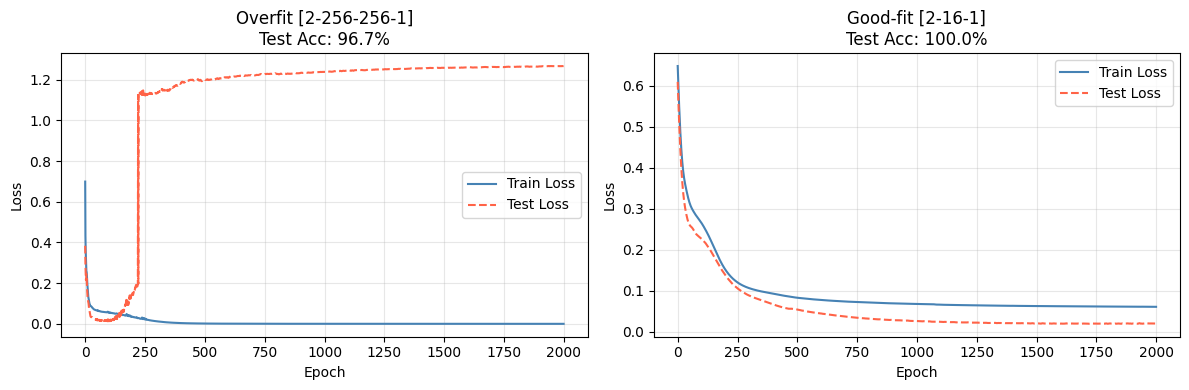

In [12]:
X_small,y_small=make_moons(n_samples=300,noise=0.2,random_state=42)
Xs_tr,Xs_te,ys_tr,ys_te=train_test_split(X_small,y_small,test_size=0.3,random_state=42)
Xstr=torch.tensor(Xs_tr,dtype=torch.float32); ystr=torch.tensor(ys_tr,dtype=torch.float32).unsqueeze(1)
Xste=torch.tensor(Xs_te,dtype=torch.float32); yste=torch.tensor(ys_te,dtype=torch.float32).unsqueeze(1)

def train_with_history(layer_dims, epochs=2000, lr=0.01):
    torch.manual_seed(42)
    model = DNN(layer_dims)                                    # ← 정답
    opt   = torch.optim.Adam(model.parameters(), lr=lr)       # ← 정답
    crit  = nn.BCELoss()                                       # ← 정답
    train_hist,test_hist=[],[]
    for _ in range(epochs):
        model.train(); opt.zero_grad(); l=crit(model(Xstr),ystr); l.backward(); opt.step()
        train_hist.append(l.item())                            # ← 정답
        model.eval()
        with torch.no_grad(): test_hist.append(crit(model(Xste),yste).item())  # ← 정답
    with torch.no_grad():
        acc=((model(Xste)>0.5).float()==yste).float().mean().item()
    return train_hist,test_hist,acc

tr_o,te_o,acc_o=train_with_history([2,256,256,1])
tr_g,te_g,acc_g=train_with_history([2,16,1])

fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,tr,te,acc,title in zip(axes,[tr_o,tr_g],[te_o,te_g],[acc_o,acc_g],
        ["Overfit [2-256-256-1]","Good-fit [2-16-1]"]):
    ax.plot(tr,label='Train Loss',color='steelblue')           # ← 정답
    ax.plot(te,label='Test Loss', color='tomato',linestyle='--')  # ← 정답
    ax.set_title(f"{title}\nTest Acc: {acc*100:.1f}%")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()
